
Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

v9- for pure permutation testing 

#### Import packages


In [1]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd

import shutil
import time
from datetime import datetime

#concurrent/parallel processing
from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from matlab_obj_to_python import load_matlab_object, check_corrupted_files

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sns_plotting_config import * #import dicts containing default plot params


# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


#### Define file config variables and analysis parameters ####

In [2]:
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")

# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/shuffles/shuffle_run_20260118_160850/config_used.yaml')

#### Set what analysis to do

In [3]:
#set parameters
data_types = ['raster', 'dff']
data_type_used = data_types[0] #OR, 'dff'
run_activity_enrichment = True
#normalization
normalize = config['preprocessing']['normalization']
if data_type_used== 'raster':
    normalize = 'none'
print(f"Applying normalization: {normalize} on {data_type_used} data")


Applying normalization: none on raster data


In [4]:
def load_all_matlab_objects(source_dir, pattern="object", verbose=True, expected_count=35):
    """Load all MATLAB object files from a directory."""
    #load files: 
    files = [f for f in source_dir.glob('**/*') if pattern in f.name]
    
    if verbose:
        print(f"Found {len(files)} files in {source_dir}")
    if expected_count:
        assert len(files) == expected_count, f"Expected {expected_count}, found {len(files)}"
    
    loaded, failed = [], []
    for i, f in enumerate(files):
        if (obj := load_matlab_object(f)) is None:
            failed.append(f.name)
        else:
            loaded.append(obj)
            if verbose:
                print(f"Loading {i+1}/{len(files)}: {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames")
    
    if verbose:
        print(f"\nLoaded {len(loaded)}/{len(files)} files")
    if failed:
        check_corrupted_files(source_dir, loaded, failed)
    
    return loaded

In [5]:
loaded_objects = load_all_matlab_objects(source_dataset_location, expected_count=35)


Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
Loading 1/35: 10_3_HET_RS1: 150415 cells × 136 frames
Loading 2/35: 10_3_HET_RS2: 97940 cells × 168 frames
Loading 3/35: 10_3_HET_RS3: 108794 cells × 157 frames
Loading 4/35: 13_3_HET_RS1: 191533 cells × 160 frames
Loading 5/35: 13_3_HET_RS2: 108651 cells × 145 frames
Loading 6/35: 13_3_HET_RS3: 128277 cells × 147 frames
Loading 7/35: 13_4_WT_RS1: 153831 cells × 183 frames
Loading 8/35: 13_4_WT_RS2: 106245 cells × 171 frames
Loading 9/35: 13_5_HET_RS1: 229350 cells × 120 frames
Loading 10/35: 13_5_HET_RS2: 141283 cells × 125 frames
Loading 11/35: 13_5_HET_RS3: 96995 cells × 131 frames
Loading 12/35: 13_6_WT_RS1: 206081 cells × 247 frames
Loading 13/35: 13_6_WT_RS2: 145514 cells × 246 frames
Loading 14/35: 13_8_HET_RS1: 124098 cells × 207 frames
Loading 15/35: 13_8_HET_RS2: 111694 cells × 206 frames
Loading 16/35: 13_8_HET_RS3: 126723 cells × 244 frames
Lo

#### Extract and Transform Matlab Objects into stage-labeled dataframes

In [6]:
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, get_intercol_corrs, read_shuffle_parquet_from_folder, pivot_trial_windows, extract_trial_windows, create_subject_trial_tseries_df
### testing
test_df = dataset_obj_to_df(loaded_objects[0],config, analysis_config,  datatype = 'raster', normalize = 'none') #test 1 dataset
print(test_df.info())
print(test_df.sample())

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 135487 entries, frame_14928 to frame_150414
Columns: 132 entries, cell_1 to truncated_post
dtypes: Int16(1), Sparse[int32, 0](121), bool(2), int32(1), object(7)
memory usage: 16.4+ MB
None
              cell_1  cell_3  cell_4  cell_5  cell_6  cell_9  cell_10  \
frame_106891       0       0       0       0       0       0        0   

              cell_11  cell_12  cell_13  ...  normalized  datatype  \
frame_106891        0        0        0  ...        none    raster   

              subject_name  geno  session  drop_inactive_cells  trial_num  \
frame_106891  10_3_HET_RS1   HET      RS1                 True         27   

              task_stage  trial_section  truncated_post  
frame_106891   

<Figure size 960x720 with 0 Axes>

In [7]:
loaded_objects[0].keys()

dict_keys(['name', 'geno', 'session', 'geno_day', 'raster', 'deduplicated', 'good_cells', 'labels', 'dff', 'spatial_weights', 'temporal_weights', 'user_labels', 'subject_name'])

In [8]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes= transform_all_datasets(loaded_objects,config, analysis_config, datatype = data_type_used, normalize = normalize)

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
 Dropping 17 cells w. 0 activity: ['cell_13', 'cell_16', 'cell_32', 'cell_35', 'cell_38', 'cell_40', 'cell_41', 'cell_49', 'cell_57', 'cell_59', 'cell_65', 'cell_75', 'cell_97', 'cell_115', 'cell_120', 'cell_135', 'cell_168']
Processed raster of 10_3_HET_RS2: 131631360 bytes
 Dropping 14 cells w. 0 activity: ['cell_10', 'cell_22', 'cell_26', 'cell_38', 'cell_40', 'cell_45', 'cell_50', 'cell_81', 'cell_87', 'cell_101', 'cell_103', 'cell_134', 'cell_136', 'cell_143']
Processed raster of 10_3_HET_RS3: 136645264 bytes
 Dropping 8 cells w. 0 activity: ['cell_4', 'cell_23', 'cell_28', 'cell_41', 'cell_91', 'cell_94', 'cell_97', 'cell_139']
Processed raster of 13_3_HET_RS1: 245162240 bytes
 Dropping 10 cells w. 0 activity: ['cell_54', 'cell_65', '

#### DEBUG: test label & post-outcome delination

In [9]:
test_meta = test_df[['labels',  'normalized', 'datatype', 'subject_name', 'geno', 'session', 'drop_inactive_cells', 'trial_num', 'task_stage', 'trial_section', 'truncated_post']]
test_meta

,labels,normalized,datatype,subject_name,geno,session,drop_inactive_cells,trial_num,task_stage,trial_section,truncated_post
frame_14928,2,none,raster,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True
frame_14929,2,none,raster,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True
frame_14930,2,none,raster,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True
frame_14931,2,none,raster,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True
frame_14932,2,none,raster,10_3_HET_RS1,HET,RS1,True,1,Early_IA_Correct,pre_outcome,True
...,...,...,...,...,...,...,...,...,...,...,...
frame_150410,15,none,raster,10_3_HET_RS1,HET,RS1,True,40,Late_RS,ITI,True
frame_150411,15,none,raster,10_3_HET_RS1,HET,RS1,True,40,Late_RS,ITI,True
frame_150412,15,none,raster,10_3_HET_RS1,HET,RS1,True,40,Late_RS,ITI,True
frame_150413,15,none,raster,10_3_HET_RS1,HET,RS1,True,40,Late_RS,ITI,True


#### Circular shuffle of frame labels 

In [10]:
# Option 1: Global seed sequence across all subjects
run_shuffles = True  #set to True to run shuffles
n_shuf_per_subject = config['shuffles']['n_shuffles_per_subject'] #default = 5000
n_shuf_per_subject = 10000
## Configuration #200 minutes for 5000 shuffles/subject on 14 cores
n_jobs=  config['shuffles']['n_cores'] -2 #base =  psutil.cpu_count(logical=False)-2  #leave 2 cores free
base_seed = config['shuffles']['base_seed'] #default: 42
n_subjects = len(raster_dataframes)

print(f"Total subjects: {n_subjects}, Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles to create: {n_subjects * n_shuf_per_subject}") 
#spikes- shuffles to create: 175000 is ~ 200 min 
# #dff- 5000 shuff is ~90 min #10,000 shuff is ~190 min

Total subjects: 35, Shuffles per subject: 10000
Total shuffles to create: 350000


In [11]:
from preprocess_functions.shuffle_methods import prepare_shuffle_data, create_shuffled_df_preconverted, log_shuffle_run, get_latest_shuffle_folder, load_latest_shuffle_run

#set shuffle storage data folder
run_output_folder = results_dir / Path(f"{data_type_used}_{normalize}_norm_ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

#set RNG info 
rng_master = np.random.default_rng(base_seed) # Generate random seeds once at the start
seed_min, seed_max = 0, 2**31 # Generate N random seeds (each will be different)


## main shuffle body
all_subject_shuffles = {} # Process each subject with their allocated seed range
if run_shuffles:
    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        subject_seeds = rng_master.integers(0,seed_max, size=n_shuf_per_subject) # Allocate unique seed range for this subject
        # Run parallel shuffles for this subject- oputputs lists
        #new desparsify func: 
        prepared_data = prepare_shuffle_data(subject_raster_df, cell_col)  # Convert once
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(delayed(create_shuffled_df_preconverted)((prepared_data, int(seed))) 
            for seed in subject_seeds
        )
        # output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(delayed(create_shuffled_df_optimized)((subject_raster_df, cell_col, int(seed))) for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)
        all_shuffle_means = all_shuffle_means.assign(**{'date_saved': datetime.now().strftime("%Y-%m-%d %H:%M"),
                                                        'n_shuffles': n_shuf_per_subject, 'subject_name': subject_name}) 
        all_subject_shuffles[subject_name] = all_shuffle_means
        all_shuffle_means.to_parquet(shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet"))   #save file
        print(f" Completed + saved {len(output_shuff)} shuffles")
    print(f"\nAll {n_subjects} subjects processed. Saving shuffled mean activity DFs to {shuffle_storage_folder}")        

 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_18-Jan-2026_10000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_18-Jan-2026_10000 shuffles\shuffled_dfs_10000_per_subject

Processing subject 1/35: 10_3_HET_RS1


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    7.8s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   12.3s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   19.3s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   29.1s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   41.6s
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:   57.1s
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  1.3min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  1.6min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  2.0min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  2.5min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  3.0min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  3.5min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  4.1min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  4.8min
[Parallel(n_jobs=12)]: Done 10000 out of 1000

 Completed + saved 10000 shuffles

Processing subject 2/35: 10_3_HET_RS2


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  28 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 328 tasks      | elapsed:    4.0s
[Parallel(n_jobs=12)]: Done 828 tasks      | elapsed:    9.8s
[Parallel(n_jobs=12)]: Done 1528 tasks      | elapsed:   17.4s
[Parallel(n_jobs=12)]: Done 2428 tasks      | elapsed:   27.7s
[Parallel(n_jobs=12)]: Done 3528 tasks      | elapsed:   40.1s
[Parallel(n_jobs=12)]: Done 4828 tasks      | elapsed:   55.2s
[Parallel(n_jobs=12)]: Done 6328 tasks      | elapsed:  1.2min
[Parallel(n_jobs=12)]: Done 8028 tasks      | elapsed:  1.5min
[Parallel(n_jobs=12)]: Done 9928 tasks      | elapsed:  1.9min
[Parallel(n_jobs=12)]: Done 9977 out of 10000 | elapsed:  1.9min remaining:    0.2s
[Parallel(n_jobs=12)]: Done 10000 out of 10000 | elapsed:  1.9min finished


 Completed + saved 10000 shuffles

Processing subject 3/35: 10_3_HET_RS3


...

 Completed + saved 10000 shuffles

Processing subject 34/35: 9_3_HET_RS2


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    5.8s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   13.8s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   25.0s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   39.5s
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:   57.3s
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  1.3min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  1.7min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  2.2min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  2.7min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  3.2min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  3.8min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  4.5min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  5.2min
[Parallel(n_jobs=12)]: Done 10000 out of 1000

 Completed + saved 10000 shuffles

Processing subject 35/35: 9_3_HET_RS3


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.8s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   10.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   23.4s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   42.3s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:  1.1min
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:  1.6min
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  2.2min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  2.8min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  3.6min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  4.4min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  5.4min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  6.4min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  7.5min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  8.7min
[Parallel(n_jobs=12)]: Done 10000 out of 1000

 Completed + saved 10000 shuffles

All 35 subjects processed. Saving shuffled mean activity DFs to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_18-Jan-2026_10000 shuffles\shuffled_dfs_10000_per_subject


#### Extract parquet files and save run record

In [12]:
run_log_df = pd.read_csv( results_dir / "shuffle_run_log.csv")
run_log_df

,timestamp,shuffle_folder,n_shuffles_per_subject,n_subjects,base_seed,shuffle_type
0,11/13/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42,NaN
1,11/14/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42,NaN
2,2025-11-15 20:30:44,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42,NaN
3,2025-11-15 20:37:06,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42,NaN
4,2025-11-18 17:59:02,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42,NaN
5,2025-11-20 16:39:50,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42,NaN
6,2025-11-21 13:45:11,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42,NaN
7,2025-11-21 20:40:07,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42,NaN
8,2025-11-22 12:31:22,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42,NaN
9,2025-12-06 12:31:49,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42,NaN


In [13]:
## create info df + save
def log_shuffle_run(results_dir: Path, shuffle_storage_folder: Path, 
                    n_shuf_per_subject: int, n_subjects: int, base_seed: int, shuffle_type = None) -> None:
    """Log a completed shuffle run to the run log CSV.
    Parameters:
    - results_dir: Directory containing the run log
    - shuffle_storage_folder: Folder where shuffle parquet files were saved
    - n_shuf_per_subject: Number of shuffles per subject
    - n_subjects: Number of subjects processed
    - base_seed: Random seed used
    """
    shuffle_run_log_path = results_dir / "shuffle_run_log.csv"

    #find shuffle type from name of save

    run_info = {'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                "shuffle_type": str(shuffle_type),
                'shuffle_folder': str(shuffle_storage_folder),
                'n_shuffles_per_subject': n_shuf_per_subject,
                'n_subjects': n_subjects,
                'base_seed': base_seed}
    # Load existing log or create new one
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        run_log_df = pd.concat([run_log_df, pd.DataFrame([run_info])], ignore_index=True)
    else:
        run_log_df = pd.DataFrame([run_info])
    # Save updated log
    run_log_df.to_csv(shuffle_run_log_path, index=False)
    print(f"Saved latest shuffle run to {shuffle_run_log_path}")

## function to read the saved log csv and determine the right folder to pick from 
def get_latest_shuffle_folder(results_dir, shuffle_type):
    """Get most recent shuffle folder for 'dff' or 'raster'."""
    log = pd.read_csv(results_dir / "shuffle_run_log.csv")
    log['type'] = log['shuffle_folder'].apply(lambda x: "dff" if "dff" in x else "raster" if "raster" in x else None)
    latest = log[log['type'] == shuffle_type].iloc[-1]
    return Path(latest['shuffle_folder']) 

## loading saved info df
def load_latest_shuffle_run(results_dir: Path, shuffle_storage_folder= None, shuffle_type_to_load = 'raster'):
    """    Load shuffles from the most recent run in the log.
    Parameters:
        results_dir: Directory containing the run log
        shuffle_storage_folder=
    Returns:
    - shuffle_storage_folder: Path to the shuffle folder
    - all_subject_shuffles: Loaded shuffle data
    - latest_run: Series with run metadata (timestamp, n_shuffles, etc.)
    """
    #new- v7- add check for what data type
    shuffle_storage_folder = get_latest_shuffle_folder(results_dir, shuffle_type_to_load)
    ## given last function folder 
    # Load all parquet files from that folder
    print(f" Loading from folder: {shuffle_storage_folder}")
    all_subject_shuffles = read_shuffle_parquet_from_folder(shuffle_storage_folder)
    return shuffle_storage_folder, all_subject_shuffles

if run_shuffles: # After generating shuffles...
    log_shuffle_run(results_dir, shuffle_storage_folder, n_shuf_per_subject, len(raster_dataframes), base_seed)
else:
    shuffle_storage_folder, all_subject_shuffles = load_latest_shuffle_run(results_dir)

Saved latest shuffle run to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffle_run_log.csv


#### Given shuffle array, run enrichment detection

In [14]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)
#optional- save ensemble info as parquet
if 'data_type' not in all_ensembles.columns:# if data_type col isn't present in the ensemble matrix, add it
    all_ensembles['data_type'] = data_type_used
new_python_ens_file = run_output_folder / Path(f"{data_type_used}_postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
print(f"Saving {new_python_ens_file}")
all_ensembles.to_parquet(new_python_ens_file)

Processing subject: 10_3_HET_RS1| 121 raster cells |121 shuffle cells


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with the requested dtype. To retain the old behavior, use `obj.astype(SparseDtype(dtype))`
  raster_df.loc[:, col] = raster_df[col].astype(float)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
Processing subject: 10_3_HET_RS2| 151 raster cells |151 shuffle cells


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with the requested dtype. To retain the old behavior, use `obj.astype(SparseDtype(dtype))`
  raster_df.loc[:, col] = raster_df[col].astype(float)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
Processing subject: 10_3_HET_RS3| 143 raster cells |143 shuffle cells


...

using exact p-value
Processing subject: 9_3_HET_RS2| 137 raster cells |137 shuffle cells


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with the requested dtype. To retain the old behavior, use `obj.astype(SparseDtype(dtype))`
  raster_df.loc[:, col] = raster_df[col].astype(float)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
Processing subject: 9_3_HET_RS3| 208 raster cells |208 shuffle cells


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: The behavior of .astype from SparseDtype to a non-sparse dtype is deprecated. In a future version, this will return a non-sparse array with the requested dtype. To retain the old behavior, use `obj.astype(SparseDtype(dtype))`
  raster_df.loc[:, col] = raster_df[col].astype(float)
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
Saving C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_18-Jan-2026_10000 shuffles\raster_postoutcome_python_ensembles_10000_shuff_18-Jan-2026_.parquet


In [15]:
all_subject_shuffles

{'10_3_HET_RS1':                           cell_1    cell_3    cell_4    cell_5    cell_6  \
 task_stage                                                                 
 Early_IA_Correct        0.000000  0.000000  0.014167  0.000000  0.000000   
 Early_IA_Error          0.143333  0.106667  0.000000  0.000000  0.000000   
 Early_RS_Correct        0.000000  0.263333  0.022222  0.013333  0.000000   
 Early_RS_Error          0.000000  0.000000  0.000000  0.000000  0.086667   
 Late_IA                 0.000000  0.000000  0.000000  0.000000  0.000000   
 ...                          ...       ...       ...       ...       ...   
 Early_RS_Correct        0.000000  0.005556  0.000000  0.000000  0.000000   
 Early_RS_Error          0.000000  0.251667  0.000000  0.000000  0.000000   
 Late_IA                 0.002000  0.018667  0.000000  0.050000  0.000000   
 Late_RS                 0.000000  0.000000  0.000000  0.000000  0.000000   
 truncated_post_outcome  0.013281  0.054219  0.004063  0.028

#### Within python latest shuffle run, compare within chunk stability


In [16]:
def chunk_shuffles_by_subject(all_subject_shuffles: Dict[str, pd.DataFrame], raster_dataframes: Dict[str, pd.DataFrame], chunk_size: int = 1000) -> pd.DataFrame:
    """ Chunk shuffles by subject into smaller sets for enrichment analysis.
    Inputs:
    all_subject_shuffles : Dict of subject_name to shuffled mean activity DataFrame
    raster_dataframes : Dict of subject_name to raster DataFrame
    chunk_size : number of unique seeds per chunk
    Returns: pd.DataFrame of combined enrichment results across all subject-chunks"""
    # Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
    print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
    chunked_ensemble_results = []
    # Loop over each subject
    for subject_name, shuffle_df in all_subject_shuffles.items():
        # Get unique seeds for THIS subject
        subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
        n_seeds = len(subject_unique_seeds)
        n_chunks = n_seeds // chunk_size
        print(f"\n=== Processing subject: {subject_name}. total seeds: {n_seeds}, {n_chunks} chunks ===")
        
        # Get corresponding raster data
        subject_raster_df = raster_dataframes[subject_name]
        cell_col = [c for c in subject_raster_df.columns if c.startswith('cell_')]
        
        # Loop over chunks for this subject
        for chunk_idx in range(n_chunks):
            # Get specific seeds for this chunk
            start_idx = chunk_idx * chunk_size
            end_idx = (chunk_idx + 1) * chunk_size
            chunk_seeds = subject_unique_seeds[start_idx:end_idx]
            chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
            # Run enrichment analysis for this subject-chunk
            chunk_ensembles = get_cell_stage_enrichment(all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, n_shuf_per_subject=len(chunk_seeds))
            # Add metadata
            chunked_ensemble_results.append(chunk_ensembles.assign(**{'subject_name': subject_name,'chunk_index': chunk_idx, 'chunk_seed_min': chunk_seeds[0],'chunk_seed_max': chunk_seeds[-1],'n_seeds_in_chunk': len(chunk_seeds)}))

    # Combine all subject-chunk results
    all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)
    print(f"Processed {all_chunked_ensembles['subject_name'].nunique()} Subjects into {all_chunked_ensembles.shape} shaped DF")
    print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")
    return all_chunked_ensembles

## pivot chunked ensembles activation and plot heatmap
def get_pivoted_enrichment_heatmap(all_chunked_ensembles: pd.DataFrame, pivot_values = 'enriched') -> pd.DataFrame:
    """ Pivot chunked ensemble enrichment results and plot heatmap of correlations.
    Inputs: all_chunked_ensembles : DataFrame with columns ['subject_name', 'task_stage', 'cell', 'chunk_index', 'enriched']
    Returns: Pivoted DataFrame of enrichment by chunk"""

    enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values=pivot_values,aggfunc='first')
    enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
    enriched_by_chunk=enriched_by_chunk.reset_index()
    return enriched_by_chunk

In [19]:
all_subject_shuffles

{'10_3_HET_RS1':                           cell_1    cell_3    cell_4    cell_5    cell_6  \
 task_stage                                                                 
 Early_IA_Correct        0.000000  0.000000  0.014167  0.000000  0.000000   
 Early_IA_Error          0.143333  0.106667  0.000000  0.000000  0.000000   
 Early_RS_Correct        0.000000  0.263333  0.022222  0.013333  0.000000   
 Early_RS_Error          0.000000  0.000000  0.000000  0.000000  0.086667   
 Late_IA                 0.000000  0.000000  0.000000  0.000000  0.000000   
 ...                          ...       ...       ...       ...       ...   
 Early_RS_Correct        0.000000  0.005556  0.000000  0.000000  0.000000   
 Early_RS_Error          0.000000  0.251667  0.000000  0.000000  0.000000   
 Late_IA                 0.002000  0.018667  0.000000  0.050000  0.000000   
 Late_RS                 0.000000  0.000000  0.000000  0.000000  0.000000   
 truncated_post_outcome  0.013281  0.054219  0.004063  0.028

In [21]:
all_chunked_ensembles = chunk_shuffles_by_subject(all_subject_shuffles, raster_dataframes, chunk_size=1000)

Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1. total seeds: 10000, 10 chunks ===


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:43: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].sparse.to_dense()


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 10_3_HET_RS2. total seeds: 10000, 10 chunks ===


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:43: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].sparse.to_dense()


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 10_3_HET_RS3. total seeds: 10000, 10 chunks ===


...

using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 9_3_HET_RS2. total seeds: 10000, 10 chunks ===


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:43: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].sparse.to_dense()


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 9_3_HET_RS3. total seeds: 10000, 10 chunks ===


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:43: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].sparse.to_dense()


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
Processed 35 Subjects into (381990, 11) shaped DF
Chunks per subject: subject_name
10_3_HET_RS1    10
10_3_HET_RS2    10
10_3_HET_RS3    10
13_3_HET_RS1    10
13_3_HET_RS2    10
13_3_HET_RS3    10
13_4_WT_RS1     10
13_4_WT_RS2     10
13_5_HET_RS1    10
13_5_HET_RS2    10
13_5_HET_RS3    10
13_6_WT_RS1     10
13_6_WT_RS2     10
13_8_HET_RS1    10
13_8_HET_RS2    10
13_8_HET_RS3    10
14_2_WT_RS1     10
14_2_WT_RS2     10
15_1_HET_RS1    10
15_1_HET_RS2    10
15_1_HET_RS3    10
5_3_WT_RS1      10
5_3_WT_RS2      10
6_2_WT_RS1      10
6_2_WT_RS2      10
7_2_WT_RS1      10
7_4_WT_RS1      10
7_5_WT_RS1      10
7_5_WT_RS2      10
7_6_HET_RS1     10
7_6_HET_RS2     10
7_6_HET_RS3     10
9_3_HET_RS1     10
9_3_HET_RS2     10
9_3_HET_RS3     10
Name: chunk_index, dtype: int64


#### import raw shuffle data for DFF and spikes, to compare shuffle chunk similarity

In [22]:
spikes_shuffle_path = results_dir / Path(f"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles/shuffled_dfs_5000_per_subject")

print(f"Loading shuffles from {spikes_shuffle_path}")
all_shuffles_spikes =  read_shuffle_parquet_from_folder(spikes_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_spikes = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'raster', normalize = 'none')
all_chunk_ens_spikes = chunk_shuffles_by_subject(all_shuffles_spikes, raster_dataframes_spikes, chunk_size=1000)
enriched_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes)
enriched_by_chunk_spikes.head()


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
 Dropping 15 cells w. 0 a

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:43: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].sparse.to_dense()
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 10_3_HET_RS2. total seeds: 5000, 5 chunks ===


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:43: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].sparse.to_dense()
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 10_3_HET_RS3. total seeds: 5000, 5 chunks ===


...

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:43: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].sparse.to_dense()
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 9_3_HET_RS3. total seeds: 5000, 5 chunks ===


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:43: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].sparse.to_dense()
c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
Processed 35 Subjects into (190995, 11) shaped DF
Chunks per subject: subject_name
10_3_HET_RS1    5
10_3_HET_RS2    5
10_3_HET_RS3    5
13_3_HET_RS1    5
13_3_HET_RS2    5
13_3_HET_RS3    5
13_4_WT_RS1     5
13_4_WT_RS2     5
13_5_HET_RS1    5
13_5_HET_RS2    5
13_5_HET_RS3    5
13_6_WT_RS1     5
13_6_WT_RS2     5
13_8_HET_RS1    5
13_8_HET_RS2    5
13_8_HET_RS3    5
14_2_WT_RS1     5
14_2_WT_RS2     5
15_1_HET_RS1    5
15_1_HET_RS2    5
15_1_HET_RS3    5
5_3_WT_RS1      5
5_3_WT_RS2      5
6_2_WT_RS1      5
6_2_WT_RS2      5
7_2_WT_RS1      5
7_4_WT_RS1      5
7_5_WT_RS1      5
7_5_WT_RS2      5
7_6_HET_RS1     5
7_6_HET_RS2     5
7_6_HET_RS3     5
9_3_HET_RS1     5
9_3_HET_RS2     5
9_3_HET_RS3     5
Name: chunk_index, dtype: int64


,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


In [23]:
#Then, get dff ensemble output: 
dff_shuffle_path = results_dir / Path(r"dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles/shuffled_dfs_5000_per_subject")
print(f"Loading shuffles from {dff_shuffle_path}")
for parquet_file in dff_shuffle_path.glob("*.parquet"):
    print(parquet_file)


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject
C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject\10_3_HET_RS1_shuffled_mean_activity.parquet
C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject\10_3_HET_RS2_shuffled_mean_activity.parquet
C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject\10_3_HET_RS3_shuffled_mean_activity.parquet
C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_de

In [24]:

all_shuffles_dff =  read_shuffle_parquet_from_folder(dff_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_dff = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'dff', normalize = 'baseline_zscore')
all_chunk_ens_dff = chunk_shuffles_by_subject(all_shuffles_dff, raster_dataframes_dff, chunk_size=1000)
enriched_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff)
enriched_by_chunk_dff.head()


 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS1: 81825760 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS2: 65815680 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 10_3_HET_RS2. total seeds: 5000, 5 chunks ===


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 10_3_HET_RS3. total seeds: 5000, 5 chunks ===


...

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value

=== Processing subject: 9_3_HET_RS3. total seeds: 5000, 5 chunks ===


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\preprocess_functions\detect_cell_enrichment.py:44: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  raster_df.loc[:, col] = raster_df[col].astype(float)


using exact p-value
using exact p-value
using exact p-value
using exact p-value
using exact p-value
Processed 35 Subjects into (197670, 11) shaped DF
Chunks per subject: subject_name
10_3_HET_RS1    5
10_3_HET_RS2    5
10_3_HET_RS3    5
13_3_HET_RS1    5
13_3_HET_RS2    5
13_3_HET_RS3    5
13_4_WT_RS1     5
13_4_WT_RS2     5
13_5_HET_RS1    5
13_5_HET_RS2    5
13_5_HET_RS3    5
13_6_WT_RS1     5
13_6_WT_RS2     5
13_8_HET_RS1    5
13_8_HET_RS2    5
13_8_HET_RS3    5
14_2_WT_RS1     5
14_2_WT_RS2     5
15_1_HET_RS1    5
15_1_HET_RS2    5
15_1_HET_RS3    5
5_3_WT_RS1      5
5_3_WT_RS2      5
6_2_WT_RS1      5
6_2_WT_RS2      5
7_2_WT_RS1      5
7_4_WT_RS1      5
7_5_WT_RS1      5
7_5_WT_RS2      5
7_6_HET_RS1     5
7_6_HET_RS2     5
7_6_HET_RS3     5
9_3_HET_RS1     5
9_3_HET_RS2     5
9_3_HET_RS3     5
Name: chunk_index, dtype: int64


,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


In [25]:
all_shuffles_dff

{'10_3_HET_RS1':                           cell_1    cell_2    cell_3    cell_4    cell_5  \
 task_stage                                                                 
 Early_IA_Correct       -0.181238  2.270742 -0.231418  0.266136 -0.208593   
 Early_IA_Error          3.866526  0.629535 -0.284084 -0.459596  0.024476   
 Early_RS_Correct       -0.233365 -0.250237 -0.121678 -0.332362 -0.248208   
 Early_RS_Error         -0.232059  0.116491 -0.278082 -0.468141  0.037643   
 Late_IA                -0.232494  0.738371 -0.222590  0.301796 -0.087362   
 ...                          ...       ...       ...       ...       ...   
 Early_RS_Correct        1.633119 -0.265683 -0.284203  0.475729 -0.262263   
 Early_RS_Error         -0.226935 -0.265766  0.145556 -0.342543 -0.259204   
 Late_IA                 1.140736 -0.188227 -0.281260  0.029042  0.071505   
 Late_RS                 0.242117 -0.264928 -0.196485 -0.261452 -0.195416   
 truncated_post_outcome  0.201533  0.187196  0.029122 -0.206

#### Plot correlation of spike and dff data enrichment

In [26]:
def plot_stage_correlation_heatmaps(enrich_compared_df: pd.DataFrame, 
                                   stage_names: list, 
                                   merge_chunk_col: list,
                                   value_compared: str,
                                   axes: np.ndarray,
                                   grid_shape: tuple = (2, 3),
                                   vmin: float = 0.5,
                                   cmap: str = 'viridis') -> None:
    """Plot correlation heatmaps for each task stage on a subplot grid."""
    nrows, ncols = grid_shape
    
    for s, stage in enumerate(stage_names):
        ax = axes.flatten()[s]
        row, col = s // ncols, s % ncols
        
        # Compute and plot correlation for this stage
        stage_vals = enrich_compared_df[enrich_compared_df['task_stage'] == stage][merge_chunk_col].corr()
        sns.heatmap(stage_vals, vmin=vmin, cmap=cmap, ax=ax)
        
        # Remove ticks if not on edges
        if col != 0: ax.set_yticks([])
        if row != nrows - 1: ax.set_xticks([])
        
        ax.set_title(f"{stage.replace('_', ' ')}: {value_compared} correlations")

Figure saved: dff_vs_spikes_ensemble_membership_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


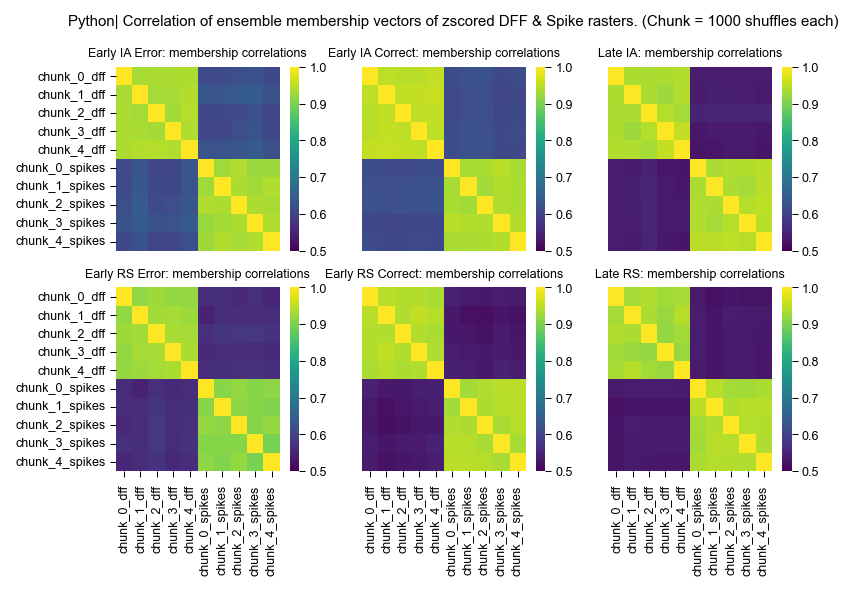

In [27]:

merged_enriched_chunks = pd.merge(enriched_by_chunk_dff, enriched_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
# Plot correlation heatmaps
value_compared = "membership"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merged_enriched_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merged_enriched_chunks.columns if 'chunk_' in c], value_compared=value_compared, axes = axes)
fig.suptitle(f"Python| Correlation of ensemble {value_compared} vectors of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes_ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

Figure saved: dff_vs_spikes_ensemble_p-value_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


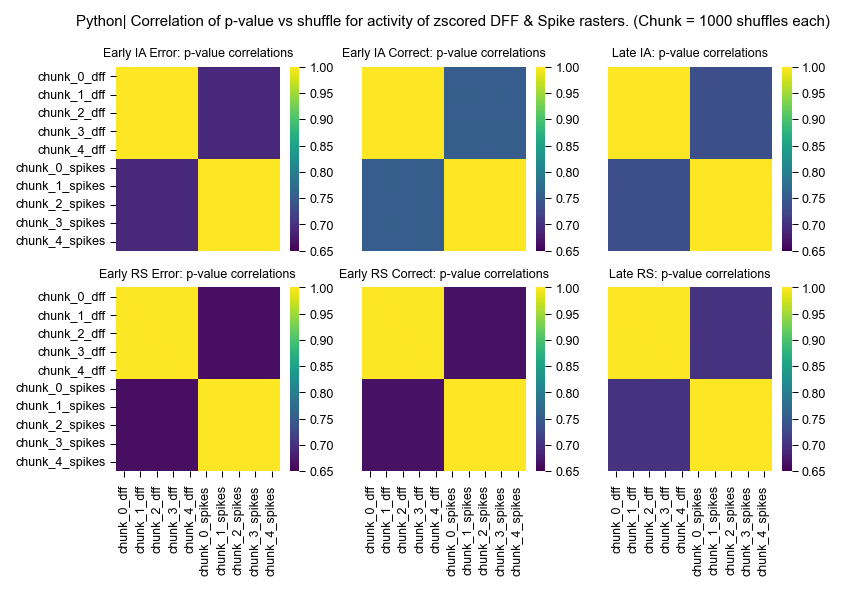

In [28]:
#use pvalue for corr 
pval_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes, pivot_values = 'percent_shuffle >= real')
pval_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff, pivot_values = 'percent_shuffle >= real')
merge_pval_chunks = pd.merge(pval_by_chunk_dff, pval_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))

# Plot correlation heatmaps
value_compared = "p-value"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merge_pval_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merge_pval_chunks.columns if 'chunk_' in c], value_compared=value_compared, vmin = 0.65, axes = axes)
fig.suptitle(f"Python| Correlation of {value_compared} vs shuffle for activity of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes_ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

#### import both DFF & spike ensemble parquets


In [29]:
# import DFF ensemble matrix- baseline Zscored
dff_ens_path = list(get_latest_shuffle_folder(results_dir, 'dff').parent.glob("*.parquet"))[0]
print(f"loading: {dff_ens_path}")
# dff_ens_path = results_dir / Path(r"dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\dff_postoutcome_python_ensembles_5000_shuff_07-Dec-2025_.parquet")
dff_ens = pd.read_parquet(dff_ens_path)
if 'data_type' not in dff_ens.columns:
    dff_ens['data_type'] = 'dff'
print(dff_ens.info())
#get ensemble info from canon df
dff_ens.tail(3)

loading: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles\dff_postoutcome_python_ensembles_10000_shuff_07-Dec-2025_.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39534 entries, 0 to 39533
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               39534 non-null  object 
 1   cell                     39534 non-null  object 
 2   percentile_95            39520 non-null  float64
 3   mean                     39520 non-null  float32
 4   enriched                 39534 non-null  bool   
 5   percent_shuffle >= real  39534 non-null  float64
 6   subject_name             39534 non-null  object 
 7   neuron_id                39534 non-null  object 
 8   date_made                39534 non-null  object 
 9   n_shuffles               39534 non-null  int64  
 10  data_type 

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
39531,Late_IA,cell_215,0.661995,-0.354924,False,0.9983,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff
39532,Late_RS,cell_215,0.726587,0.001032,False,0.3358,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff
39533,truncated_post_outcome,cell_215,0.174152,-0.165721,False,0.9979,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff


In [30]:
#import last spikes ensemble matrix for comparison
#non normalized mean spike rate for the means 
spikes_ens_path = list(get_latest_shuffle_folder(results_dir, 'raster').parent.glob("*.parquet"))[0]
print(f"Loading: {spikes_ens_path}") # spikes_ens_path = results_dir / Path(r"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles\raster_postoutcome_python_ensembles_5000_shuff_06-Dec-2025_.parquet")
spikes_ens = pd.read_parquet(spikes_ens_path)
if 'data_type' not in spikes_ens.columns:
    spikes_ens['data_type'] = 'spikes'
print(spikes_ens.info())
spikes_ens.tail(3)

Loading: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_18-Jan-2026_10000 shuffles\raster_postoutcome_python_ensembles_10000_shuff_18-Jan-2026_.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38199 entries, 0 to 38198
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               38199 non-null  object 
 1   cell                     38199 non-null  object 
 2   percentile_95            38199 non-null  float64
 3   mean                     38199 non-null  float64
 4   enriched                 38199 non-null  bool   
 5   percent_shuffle >= real  38199 non-null  float64
 6   subject_name             38199 non-null  object 
 7   neuron_id                38199 non-null  object 
 8   date_made                38199 non-null  object 
 9   n_shuffles               38199 non-null  int64  
 10  data_type      

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
38196,Late_IA,cell_99,0.017333,0.000000,False,1.000000,9_3_HET_RS3,9_3_HET_RS3-99,18-Jan-2026,10000,raster
38197,Late_RS,cell_99,0.018333,0.000000,False,1.000000,9_3_HET_RS3,9_3_HET_RS3-99,18-Jan-2026,10000,raster
38198,truncated_post_outcome,cell_99,0.006127,0.002014,False,0.607839,9_3_HET_RS3,9_3_HET_RS3-99,18-Jan-2026,10000,raster


In [31]:
## pivot both enrichment vectors, then merge
spikes_ens_matrix = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
dff_ens_matrix = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
compare_spike_dff_ens = spikes_ens_matrix.merge(dff_ens_matrix, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_ens.info())
compare_spike_dff_ens.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5470 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5470 non-null   float64
 1   Early_IA_Error_spikes          4441 non-null   float64
 2   Early_RS_Correct_spikes        5470 non-null   float64
 3   Early_RS_Error_spikes          5470 non-null   float64
 4   Late_IA_spikes                 5470 non-null   float64
 5   Late_RS_spikes                 5470 non-null   float64
 6   truncated_post_outcome_spikes  5470 non-null   float64
 7   Early_IA_Correct_dff           5470 non-null   float64
 8   Early_IA_Error_dff             4441 non-null   float64
 9   Early_RS_Correct_dff           5470 non-null   float64
 10  Early_RS_Error_dff             5470 non-null   float64
 11  Late_IA_dff                    5470 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-10,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
df = compare_spike_dff_ens
correlations = {stage: df[stage+"_spikes"].corr(df[stage + '_dff']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.624613
Early_IA_Correct     0.614595
Late_IA              0.550077
Early_RS_Error       0.574041
Early_RS_Correct     0.525900
Late_RS              0.535796


In [33]:
## pivot both p-value matrices, then merge
spikes_ens_pval = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
dff_ens_pval = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
compare_spike_dff_p = spikes_ens_pval.merge(dff_ens_pval, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_p.info())
compare_spike_dff_p.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5470 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5470 non-null   float64
 1   Early_IA_Error_spikes          5470 non-null   float64
 2   Early_RS_Correct_spikes        5470 non-null   float64
 3   Early_RS_Error_spikes          5470 non-null   float64
 4   Late_IA_spikes                 5470 non-null   float64
 5   Late_RS_spikes                 5470 non-null   float64
 6   truncated_post_outcome_spikes  5470 non-null   float64
 7   Early_IA_Correct_dff           5470 non-null   float64
 8   Early_IA_Error_dff             5470 non-null   float64
 9   Early_RS_Correct_dff           5470 non-null   float64
 10  Early_RS_Error_dff             5470 non-null   float64
 11  Late_IA_dff                    5470 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.242076,0.0009,1.000000,1.0,1.0,1.0,0.015098,0.3701,0.0007,0.2501,0.7499,0.5230,0.7730,0.0118
10_3_HET_RS1-10,0.252575,0.0014,1.000000,1.0,1.0,1.0,0.001800,0.1555,0.0046,1.0000,0.0548,0.9665,0.7555,0.0001
10_3_HET_RS1-100,1.000000,1.0000,0.438356,1.0,1.0,1.0,0.757624,0.9762,0.8332,0.6920,0.9575,0.9946,0.9888,0.9445


In [34]:
corr_df = get_intercol_corrs(compare_spike_dff_p, stage_names, suffix1="_spikes", suffix2="_dff")
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.782429
Early_IA_Correct     0.753088
Late_IA              0.734657
Early_RS_Error       0.663554
Early_RS_Correct     0.666088
Late_RS              0.702068


#### Threshold time-series df to remove 0 

In [35]:
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import annotate_csv, run_min_max_norm_on_timeseries


In [37]:
#for concordance with previous code, need to label the stage col as 'task_stage_vec
stage_col = 'task_phase_vec'

def normalize_tseries_df(trial_tseries_df_raw: pd.DataFrame,
                          n_end_timebins_to_drop = config['timeseries']['n_end_timebins_to_drop'], #default = 0,
                          n_start_timebins_to_drop = config['timeseries']['n_start_timebins_to_drop'], #default = 8,
                          name_col: str = 'subject_name',
                          neuron_id_col: str = 'neuron_id',
                          min_max_type: str = 'nonneg',
                          ) -> pd.DataFrame:
    """ Normalize trial time-series DataFrame based on normalization type.
    Inputs:
    trial_tseries_df_raw : DataFrame with raw time-series data (ALREADY BINNED)
    hyper_param_dict : dictionary of hyperparameters
    outcome_post : DataFrame with outcome post data

    Returns: Normalized trial time-series DataFrame
    """
    #get normalization info for curr df
    normed = trial_tseries_df_raw['normalized'].unique()[0]
    if normed == 'none':
        use_min_max_norm = True 
    else:
        use_min_max_norm = False
    print(f" Data Normalization type: {normed} | Applying min-max norm? {use_min_max_norm} ")
    
    numeric_col = get_numeric_cols_timeseries(trial_tseries_df_raw, " to ") 
    print(numeric_col)
    #is min-max norm run BEFORE or AFTER bin dropping? 
    trial_tseries_df_norm = run_min_max_norm_on_timeseries(use_min_max_norm,
                                                            trial_tseries_df_raw,
                                                              [name_col, neuron_id_col],
                                                                numeric_col, 
                                                                'max_trial_val_all_time') #min_max_norm = True
    
    #To-do add min max normalization flag to either use non-neg timebins or not
    trial_tseries_df_norm['min_max_type'] = min_max_type
    #get mean of each trial- IS this run BEFORE or AFTER norm? 
    use_neg_timebin_in_mean = True #include pre-outcome bins in mean rate calc
    if use_neg_timebin_in_mean:
        trial_tseries_df_norm['mean_rate_in_trial'] =trial_tseries_df_norm[numeric_col].mean(axis = 1)
    else:
        trial_tseries_df_norm['mean_rate_in_trial'] =trial_tseries_df_norm[[c for c in numeric_col if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
    trial_tseries_df_norm['cell_is_active_in_trial'] =trial_tseries_df_norm['mean_rate_in_trial']>0

    #OPTIONAL- drop N bins from start and M bins from end of time-series
    #first, check if you're pre-truncated the data (e.g. already only sliced 3 seconds before outcome)
    neg_timebins = [c for c in numeric_col if "-" in c]
    if len(neg_timebins) <4*3+1: #if you only have 1 second or so of pre-outcome data, you've already sliced 
        n_start_timebins_to_drop = 0
    trial_tseries_df_norm = drop_end_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_end_timebins_to_drop = n_end_timebins_to_drop )
    trial_tseries_df_norm = drop_start_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_start_timebins_to_drop =n_start_timebins_to_drop)
    return trial_tseries_df_norm

def normalize_all_subject_tseries_dfs(raster_base_dfs: Dict[str, pd.DataFrame],
                                      config = config, 
                                      n_end_timebins_to_drop = 0,
                                      n_start_timebins_to_drop = 8,
                                      name_col: str = 'subject_name',
                                      neuron_id_col: str = 'neuron_id',
                                      ) -> pd.DataFrame:
    """ Normalize all subject trial time-series DataFrames.
    Inputs:     raster_base_dfs : Dict of subject_name to raw full recording matrix DataFrame
    optional settings for time-series normalization that equal defaults, so left un input

    Returns: concat. dataframe of subject_name to normalized trial time-series DataFrame
    """

    raster_timeseries =[]
    for name, raster_df in raster_base_dfs.items():
        print(f" Reshaping tseries of {name}: {raster_df.shape}")    
        subj_trial_tseries_df_raw= create_subject_trial_tseries_df(raster_df, dff_ens_matrix, config = config)
        subj_trial_tseries_df_norm= normalize_tseries_df(subj_trial_tseries_df_raw, min_max_type= config['min_max_type'],)
        raster_timeseries.append(subj_trial_tseries_df_norm)
    trial_tseries_df_norm = pd.concat(raster_timeseries)
    return trial_tseries_df_norm

In [ ]:

"""
#call normalize_all_subject_tseries_dfs() 
-> calls create_subject_trial_tseries_df()

-> calls normalize_tseries_df()
- > -> calls run_min_max_norm_on_timeseries()
->->-> calls get_unit_max_event_rate_of_all_trials() if run_norm is true
    sets max_val_col_name = 'max_trial_val'

"""




In [41]:
config

{'data': {'root_dir': WindowsPath('c:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/code'),
  'data_dir': WindowsPath('c:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/data'),
  'results_dir': WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results'),
  'source_dataset_date': '24-Nov-2024_hour_19',
  'source_dataset_location': WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/data/dataset_objects_24-Nov-2024_hour_19'),
  'data_types': ['spikes', 'dff'],
  'data_type_used': 'dff'},
 'preprocessing': {'gaussian_sigma': 1,
  'gaussian_truncate': 1.0,
  'normalization': 'baseline_zscore',
  'post_outcome_duration': 15,
  'truncate_post_outcome': True,
  'drop_inactive_cells': True},
 'shuffles': {'run_shuffles': False,
  'n_shuffles_per_subject': 5000,
  'base_seed': 42,
  'cores_to_leave_free': 2,
  'chunk_size': 1000,
  'n_cores': 14},
 'timeseries': {'fps': 20,
 

In [39]:
min_max_type = 'nonneg_frames' #options: 'all_frames', 'nonneg_frames'
config['min_max_type'] = min_max_type
print(f"Applying min-max normalization type: {min_max_type}")
trial_tseries_df_norm = normalize_all_subject_tseries_dfs(raster_dataframes, config = config)
trial_tseries_df_norm


Applying min-max normalization type: nonneg_frames
 Reshaping tseries of 10_3_HET_RS1: (135487, 132)
Using 0 pre-outcome frames
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
 Data Normalization type: none | Applying min-max norm? True 
Index(['-5.0s to -4.75s', '-4.75s to -4.5s', '-4.5s to -4.25s',
       '-4.25s to -4.0s', '-4.0s to -3.75s', '-3.75s to -3.5s',
       '-3.5s to -3.25s', '-3.25s to -3.0s', '-3.0s to -2.75s',
       '-2.75s to -2.5s', '-2.5s to -2.25s', '-2.25s to -2.0s',
       '-2.0s to -1.75s', '-1.75s to -1.5s', '-1.5s to -1.25s',
       '-1.25s to -1.0s', '-1.0s to -0.75s', '-0.75s to -0.5s',
       '-0.5s to -0.25s', '-0.25s to -0.0s', '0.0s to 0.25s', '0.25s to 0.5s',
       '0.5s to 0.75s', '0.75s to 1.0s', '1.0s to 1.25s', '1.25s to 1.5s',
       '1.5s to 1.75s', '1.75s to 2.0s', '2.0s to 2.25s', '2.25s to 2.5s',
   

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\preprocess_data.py:375: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  enrichment_merged_act_df.loc[mask, 'enriched_in_phase'] = enrichment_merged_act_df[phase] == 1


Using 0 pre-outcome frames
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
 Data Normalization type: none | Applying min-max norm? True 
Index(['-5.0s to -4.75s', '-4.75s to -4.5s', '-4.5s to -4.25s',
       '-4.25s to -4.0s', '-4.0s to -3.75s', '-3.75s to -3.5s',
       '-3.5s to -3.25s', '-3.25s to -3.0s', '-3.0s to -2.75s',
       '-2.75s to -2.5s', '-2.5s to -2.25s', '-2.25s to -2.0s',
       '-2.0s to -1.75s', '-1.75s to -1.5s', '-1.5s to -1.25s',
       '-1.25s to -1.0s', '-1.0s to -0.75s', '-0.75s to -0.5s',
       '-0.5s to -0.25s', '-0.25s to -0.0s', '0.0s to 0.25s', '0.25s to 0.5s',
       '0.5s to 0.75s', '0.75s to 1.0s', '1.0s to 1.25s', '1.25s to 1.5s',
       '1.5s to 1.75s', '1.75s to 2.0s', '2.0s to 2.25s', '2.25s to 2.5s',
       '2.5s to 2.75s', '2.75s to 3.0s', '3.0s to 3.25s', '3.25s to 3.5s',
       '3.5s to 3.75s', '3.75

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\preprocess_data.py:375: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  enrichment_merged_act_df.loc[mask, 'enriched_in_phase'] = enrichment_merged_act_df[phase] == 1


Using 0 pre-outcome frames
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
 Data Normalization type: none | Applying min-max norm? True 
Index(['-5.0s to -4.75s', '-4.75s to -4.5s', '-4.5s to -4.25s',
       '-4.25s to -4.0s', '-4.0s to -3.75s', '-3.75s to -3.5s',
       '-3.5s to -3.25s', '-3.25s to -3.0s', '-3.0s to -2.75s',
       '-2.75s to -2.5s', '-2.5s to -2.25s', '-2.25s to -2.0s',
       '-2.0s to -1.75s', '-1.75s to -1.5s', '-1.5s to -1.25s',
       '-1.25s to -1.0s', '-1.0s to -0.75s', '-0.75s to -0.5s',
       '-0.5s to -0.25s', '-0.25s to -0.0s', '0.0s to 0.25s', '0.25s to 0.5s',
       '0.5s to 0.75s', '0.75s to 1.0s', '1.0s to 1.25s', '1.25s to 1.5s',
       '1.5s to 1.75s', '1.75s to 2.0s', '2.0s to 2.25s', '2.25s to 2.5s',
       '2.5s to 2.75s', '2.75s to 3.0s', '3.0s to 3.25s', '3.25s to 3.5s',
       '3.5s to 3.75s', '3.75

...

Using 0 pre-outcome frames
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
 Data Normalization type: none | Applying min-max norm? True 
Index(['-5.0s to -4.75s', '-4.75s to -4.5s', '-4.5s to -4.25s',
       '-4.25s to -4.0s', '-4.0s to -3.75s', '-3.75s to -3.5s',
       '-3.5s to -3.25s', '-3.25s to -3.0s', '-3.0s to -2.75s',
       '-2.75s to -2.5s', '-2.5s to -2.25s', '-2.25s to -2.0s',
       '-2.0s to -1.75s', '-1.75s to -1.5s', '-1.5s to -1.25s',
       '-1.25s to -1.0s', '-1.0s to -0.75s', '-0.75s to -0.5s',
       '-0.5s to -0.25s', '-0.25s to -0.0s', '0.0s to 0.25s', '0.25s to 0.5s',
       '0.5s to 0.75s', '0.75s to 1.0s', '1.0s to 1.25s', '1.25s to 1.5s',
       '1.5s to 1.75s', '1.75s to 2.0s', '2.0s to 2.25s', '2.25s to 2.5s',
       '2.5s to 2.75s', '2.75s to 3.0s', '3.0s to 3.25s', '3.25s to 3.5s',
       '3.5s to 3.75s', '3.75

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\preprocess_data.py:375: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  enrichment_merged_act_df.loc[mask, 'enriched_in_phase'] = enrichment_merged_act_df[phase] == 1


Using 0 pre-outcome frames
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
 Data Normalization type: none | Applying min-max norm? True 
Index(['-5.0s to -4.75s', '-4.75s to -4.5s', '-4.5s to -4.25s',
       '-4.25s to -4.0s', '-4.0s to -3.75s', '-3.75s to -3.5s',
       '-3.5s to -3.25s', '-3.25s to -3.0s', '-3.0s to -2.75s',
       '-2.75s to -2.5s', '-2.5s to -2.25s', '-2.25s to -2.0s',
       '-2.0s to -1.75s', '-1.75s to -1.5s', '-1.5s to -1.25s',
       '-1.25s to -1.0s', '-1.0s to -0.75s', '-0.75s to -0.5s',
       '-0.5s to -0.25s', '-0.25s to -0.0s', '0.0s to 0.25s', '0.25s to 0.5s',
       '0.5s to 0.75s', '0.75s to 1.0s', '1.0s to 1.25s', '1.25s to 1.5s',
       '1.5s to 1.75s', '1.75s to 2.0s', '2.0s to 2.25s', '2.25s to 2.5s',
       '2.5s to 2.75s', '2.75s to 3.0s', '3.0s to 3.25s', '3.25s to 3.5s',
       '3.5s to 3.75s', '3.75

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\preprocess_data.py:375: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  enrichment_merged_act_df.loc[mask, 'enriched_in_phase'] = enrichment_merged_act_df[phase] == 1


,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial
0,1,cell_1,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-1,1,...,0.0,0.0,0.0,1.0,1.0,False,1.0,nonneg_frames,0.0,False
1,1,cell_10,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-10,1,...,0.0,0.0,0.0,1.0,1.0,False,1.0,nonneg_frames,0.0,False
3,1,cell_101,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-101,1,...,0.0,0.0,0.0,0.0,0.0,False,1.0,nonneg_frames,0.0,False
5,1,cell_104,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-104,1,...,1.0,1.0,0.0,1.0,4.0,True,1.0,nonneg_frames,0.0,False
8,1,cell_107,10_3_HET_RS1,RS1,HET,Early_IA_Correct,none,raster,10_3_HET_RS1-107,1,...,0.0,0.0,1.0,1.0,1.0,False,1.0,nonneg_frames,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3947,38,cell_95,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-95,3,...,0.0,0.0,0.0,0.0,1.0,False,1.0,nonneg_frames,0.0,False
3948,38,cell_96,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-96,3,...,0.0,0.0,0.0,0.0,0.0,False,1.0,nonneg_frames,0.0,False
3949,38,cell_97,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-97,3,...,0.0,0.0,0.0,0.0,0.0,False,1.0,nonneg_frames,0.0,False
3950,38,cell_98,9_3_HET_RS3,RS3,HET,Late_RS,none,raster,9_3_HET_RS3-98,3,...,0.0,0.0,0.0,0.0,0.0,False,1.0,nonneg_frames,0.0,False


In [40]:

# get mean time-series value
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")  #update post drop
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['subject_name', 'neuron_id','geno_day', stage_col], numeric_col) 
unit_mean_tseries


,subject_name,neuron_id,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,truncated_post_outcome,any_enrichment,enriched_in_phase,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial,max_val,max_val_tbin,mean_rate
0,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Correct,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,False,1.0,nonneg_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
1,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Error,0.0,0.0,0.0,0.0,0.0,0.8,...,1.0,1.0,True,1.0,nonneg_frames,0.6025,True,1.0,-1.5s to -1.25s,0.690000
2,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Correct,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,False,1.0,nonneg_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
3,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,False,1.0,nonneg_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
4,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Late_IA,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,False,1.0,nonneg_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27604,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_IA_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,False,1.0,nonneg_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
27605,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Correct,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,False,1.0,nonneg_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
27606,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Error,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,False,1.0,nonneg_frames,0.0000,False,0.0,-3.0s to -2.75s,0.000000
27607,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_IA,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,False,1.0,nonneg_frames,0.0350,True,0.2,4.0s to 4.25s,0.009333


In [57]:
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['neuron_id'].nunique()
print(n_total_units)
print(n_total_units.sum())
#save filename with data type and date info
save_name = data_dir / Path(f"python-made_trial_timeseries_{min_max_type}_minmax_{data_type_used}_{datetime.now().strftime("%Y-%m-%d %H")}.parquet")
print(f"saving file as {save_name}")
trial_tseries_df_norm.to_parquet(save_name)


geno_day
Het CLNZ         858
Het VEH          873
Het postCLNZ     934
WT CLNZ         1013
WT VEH          1071
Name: neuron_id, dtype: int64
4749
saving file as c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\python-made_trial_timeseries_nonneg_frames_minmax_raster_2026-01-19 09.parquet


#### Import canon ensemble + tseries to compare umap

In [43]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = data_dir / Path(r"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file) #normalized spike rates for the means 
print(canonical_data.info())

canonical_data

<class 'pandas.core.frame.DataFrame'>
Int64Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.000000,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.000000,False
4,Early_IA_Correct,IA,Correct,1,5,10_3_HET_RS1,1,HET,Het VEH,1.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-5,1.0,0.193333,True
5,Early_IA_Correct,IA,Correct,1,6,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-6,1.0,0.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116370,Late_RS,RS,Correct,38,209,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,1.0,9_3_HET_RS3-209,1.0,0.020000,True
116373,Late_RS,RS,Correct,38,212,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,2.0,9_3_HET_RS3-212,1.0,0.030000,True
116374,Late_RS,RS,Correct,38,213,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-213,1.0,0.000000,False
116375,Late_RS,RS,Correct,38,214,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-214,1.0,0.200000,True


In [44]:
#get canon mean unit timeseries
numeric_col_canon = get_numeric_cols_timeseries(canonical_data, " to ")  #update post drop\
canon_mean_unit_tseries  =  get_unit_mean_timeseries_by_phase(canonical_data,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col) 
print(canon_mean_unit_tseries.groupby(by = 'geno_day')['unique_ID'].nunique())
print(canon_mean_unit_tseries.info())
canon_mean_unit_tseries


geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: unique_ID, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27768 entries, 0 to 27767
Data columns (total 94 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               27768 non-null  object 
 1   neuron_ID          27768 non-null  int64  
 2   geno_day           27768 non-null  object 
 3   task_phase_vec     27768 non-null  object 
 4   -3.0s to -2.75s    27768 non-null  float64
 5   -2.75s to -2.5s    27768 non-null  float64
 6   -2.5s to -2.25s    27768 non-null  float64
 7   -2.25s to -2.0s    27768 non-null  float64
 8   -2.0s to -1.75s    27768 non-null  float64
 9   -1.75s to -1.5s    27768 non-null  float64
 10  -1.5s to -1.25s    27768 non-null  float64
 11  -1.25s to -1.0s    27768 non-null  float64
 12  -1.0s to -0.75s    27768 non-null  float64
 13  -0.75s to -0.5s    277

,name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial,max_val,max_val_tbin
0,10_3_HET_RS1,1,Het VEH,Early_IA_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
1,10_3_HET_RS1,1,Het VEH,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.8000,...,0.0,0.0,True,1.0,10_3_HET_RS1-1,1.0,0.690000,True,1.0000,-1.5s to -1.25s
2,10_3_HET_RS1,1,Het VEH,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
3,10_3_HET_RS1,1,Het VEH,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
4,10_3_HET_RS1,1,Het VEH,Late_IA,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27763,9_3_HET_RS3,215,Het postCLNZ,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27764,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27765,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27766,9_3_HET_RS3,215,Het postCLNZ,Late_IA,0.05,0.00,0.2,0.0,0.2,0.0500,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.2000,-2.5s to -2.25s


#### UMAP on enrichment matrices

In [45]:
# UMAP analysis on ensemble matrices
# # Determine first active stage for each neuron
def get_first_active_stage(row, stage_order,  non_enriched_label = 'Never'):
    """Find the first stage where neuron is enriched (value = 1)"""
    for stage in stage_order:
        if stage in row.index and row[stage] == 1:
            return stage
    return non_enriched_label

def run_dimensionality_reduction(ensemble_matrix, method='umap', metric='cosine', random_state=42, **method_kwargs):
    """Run UMAP or t-SNE on ensemble matrix. Returns (df, model)."""
    from sklearn.manifold import TSNE
    import umap
    import pandas as pd
    complete_data = ensemble_matrix.dropna()
    print(f"Shape: {ensemble_matrix.shape} → {complete_data.shape}")
    
    if method.lower() == 'umap':
        model = umap.UMAP(n_neighbors=method_kwargs.get('n_neighbors', 15), min_dist=method_kwargs.get('min_dist', 0.1), 
                          metric=metric, random_state=random_state)
    elif method.lower() == 'tsne':
        model = TSNE(perplexity=method_kwargs.get('perplexity', 30), learning_rate=method_kwargs.get('learning_rate', 200), n_iter=method_kwargs.get('n_iter', 1000),
            metric=metric, random_state=random_state)
    else:
        raise ValueError(f"method must be 'umap' or 'tsne', got '{method}'")
    
    embedding = model.fit_transform(complete_data)
    results_df = pd.DataFrame({'dim1': embedding[:, 0], 'dim2': embedding[:, 1], 'method': method.upper()}, index=complete_data.index)
    return results_df, model

In [46]:
#set umap params
value_to_project = 'mean'
metric = 'cosine'

#package spikes + dff for umap processing 
spike_umap_input = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)
dff_umap_input = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)

# Run UMAP on both spike and DFF ensemble matrices
spikes_df, umap_spikes_model = run_dimensionality_reduction( spike_umap_input, method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)
dff_df, umap_dff_model = run_dimensionality_reduction(dff_umap_input.replace([np.inf, -np.inf], np.nan).fillna(0), method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric, random_state=42)

#join umap dfs with ensemble enrichment info
spike_cell_enrich = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
spikes_df = spikes_df.merge(spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)

dff_cell_enrich = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
dff_df = dff_df.merge(dff_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)


Shape: (5604, 6) → (5604, 6)
Shape: (5801, 6) → (5801, 6)


#### NEW- project by genotype into UMAP space

#### evaluate diff of canon timeseries spikes with new psikes

In [47]:
#new- 12/3/25- import canon timeseries + taco
#make pivot of mean activity of cell over its timeseries 
canon_spike_umap_input = canon_mean_unit_tseries.pivot_table(index = ['unique_ID'], columns = 'task_phase_vec', values = 'mean_rate', fill_value = False)
spike_mean_concat = pd.merge(canon_spike_umap_input, unit_mean_tseries.pivot_table(index = ['neuron_id'], columns = 'task_phase_vec', values = 'mean_rate', fill_value = False),
                               how = 'inner', left_index = True, right_index = True, suffixes=  ('_canon','_new'))
spike_mean_concat.head()

task_phase_vec,Early_IA_Correct_canon,Early_IA_Error_canon,Early_RS_Correct_canon,Early_RS_Error_canon,Late_IA_canon,Late_RS_canon,Early_IA_Correct_new,Early_IA_Error_new,Early_RS_Correct_new,Early_RS_Error_new,Late_IA_new,Late_RS_new
10_3_HET_RS1-1,0.000000,0.69,0.000000,0.000000,0.000000,0.000,0.000000,0.69,0.000000,0.000000,0.000000,0.000
10_3_HET_RS1-10,0.057500,0.476667,0.000000,0.096667,0.019333,0.000,0.057500,0.476667,0.000000,0.096667,0.019333,0.000
10_3_HET_RS1-101,0.000000,0.0,0.000000,0.000000,0.022000,0.000,0.000000,0.0,0.000000,0.000000,0.022000,0.000
10_3_HET_RS1-104,0.054167,0.0,0.012222,0.166667,0.084667,0.014,0.054167,0.0,0.012222,0.166667,0.084667,0.014
10_3_HET_RS1-107,0.000000,0.0,0.082222,0.086667,0.000667,0.004,0.000000,0.0,0.082222,0.086667,0.000667,0.004


In [48]:
canon_spike_umap_input

task_phase_vec,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
unique_ID,,,,,,
10_3_HET_RS1-1,0.000000,0.69,0.000000,0.000000,0.000000,0.000
10_3_HET_RS1-10,0.057500,0.476667,0.000000,0.096667,0.019333,0.000
10_3_HET_RS1-101,0.000000,0.0,0.000000,0.000000,0.022000,0.000
10_3_HET_RS1-104,0.054167,0.0,0.012222,0.166667,0.084667,0.014
10_3_HET_RS1-107,0.000000,0.0,0.082222,0.086667,0.000667,0.004
...,...,...,...,...,...,...
9_3_HET_RS3-95,0.000000,0.026667,0.000000,0.000000,0.000000,0.000
9_3_HET_RS3-96,0.000000,0.1775,0.093333,0.000000,0.000000,0.000
9_3_HET_RS3-97,0.033333,0.123333,0.000000,0.000000,0.000000,0.000


       Early_IA_Error  Early_IA_Correct  Late_IA  Early_RS_Error  \
count          4749.0            4749.0   4749.0          4749.0   
mean              0.0               0.0      0.0             0.0   
std               0.0               0.0      0.0             0.0   
min               0.0               0.0      0.0             0.0   
25%               0.0               0.0      0.0             0.0   
50%               0.0               0.0      0.0             0.0   
75%               0.0               0.0      0.0             0.0   
max               0.0               0.0      0.0             0.0   

       Early_RS_Correct  Late_RS  
count            4749.0   4749.0  
mean                0.0      0.0  
std                 0.0      0.0  
min                 0.0      0.0  
25%                 0.0      0.0  
50%                 0.0      0.0  
75%                 0.0      0.0  
max                 0.0      0.0  


<Axes: >

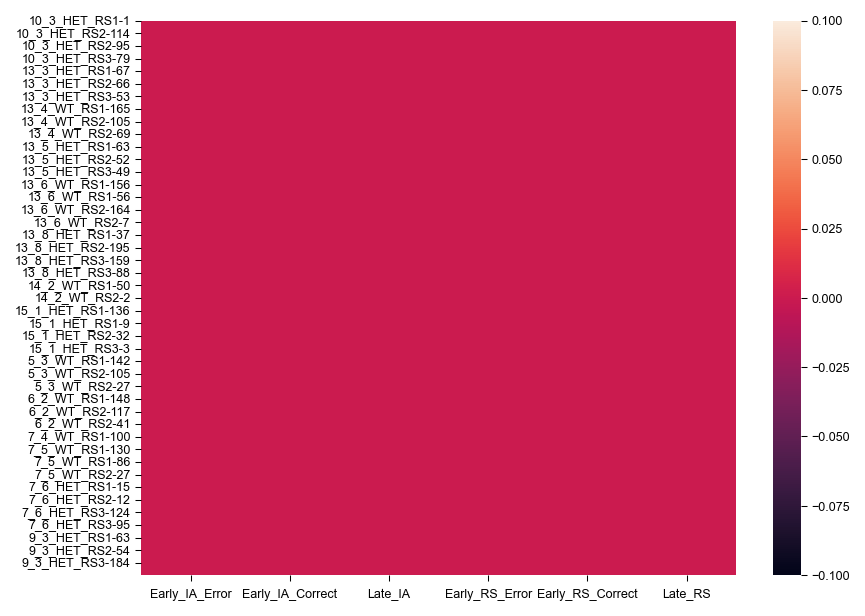

In [49]:
diff_cols = {s: (spike_mean_concat[s+"_canon"]- spike_mean_concat[s+"_new"]).astype(float) for s in stage_names}
canon_less_new_mean= pd.DataFrame(diff_cols)
#describe + plot
print(canon_less_new_mean.describe())
sns.heatmap(canon_less_new_mean.astype(float))

#### slice changed cells to further investigate

In [50]:
canon_cell_diff_bool = canon_less_new_mean != 0
canon_cell_diff_bool

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
10_3_HET_RS1-1,False,False,False,False,False,False
10_3_HET_RS1-10,False,False,False,False,False,False
10_3_HET_RS1-101,False,False,False,False,False,False
10_3_HET_RS1-104,False,False,False,False,False,False
10_3_HET_RS1-107,False,False,False,False,False,False
...,...,...,...,...,...,...
9_3_HET_RS3-95,False,False,False,False,False,False
9_3_HET_RS3-96,False,False,False,False,False,False
9_3_HET_RS3-97,False,False,False,False,False,False
9_3_HET_RS3-98,False,False,False,False,False,False


#### Plot low-D projections: UMAP

In [51]:
canon_spikes_df, canon_umap_spikes_model = run_dimensionality_reduction( canon_spike_umap_input, method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)

canon_spike_cell_enrich = canon_mean_unit_tseries.groupby(by = 'unique_ID')[stage_names].first().astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
canon_spikes_df = canon_spikes_df.merge(canon_spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)
canon_spikes_df

Shape: (4776, 6) → (4776, 6)


,dim1,dim2,method,first_active_stage
unique_ID,,,,
10_3_HET_RS1-1,14.805202,28.815002,UMAP,Early_IA_Error
10_3_HET_RS1-10,9.128179,11.871598,UMAP,Early_IA_Error
10_3_HET_RS1-101,10.173052,-23.870588,UMAP,Never
10_3_HET_RS1-104,10.593336,6.420357,UMAP,Late_IA
10_3_HET_RS1-107,12.902940,5.238976,UMAP,Never
...,...,...,...,...
9_3_HET_RS3-95,14.760444,28.685123,UMAP,Never
9_3_HET_RS3-96,11.172892,11.194283,UMAP,Never
9_3_HET_RS3-97,6.789260,12.738197,UMAP,Early_IA_Error


In [52]:
# #plot nonenriched
# non_ensemble_df =  tsne_results[geno].loc[tsne_results[geno].ensemble == 'none',:]
# sns.scatterplot(**plot_params, data =non_ensemble_df,   s = 5,alpha = 0.5, linewidth =0.5, legend = False, palette = ['black'],  zorder=-1000)
# #find collections with > 1 point contained therein
# nonlegend_collections = [x for x in ax.collections if x.get_facecolors().shape[0]>1]
# collection_size= [x.get_facecolors().shape for x in nonlegend_collections]
# largest_collection_size = np.max(collection_size) #use largest collection as == ensemble 
# non_enrich_collection = [x for x in nonlegend_collections if x.get_facecolors().shape[0] == largest_collection_size][0]
# non_enrich_collection.set_edgecolors(non_enrich_collection.get_facecolors().copy())# Restore the edge colors using the saved values
# non_enrich_collection.set_facecolors("none")# Remove the face color by setting it to "none"
# #plot ensemble
# ensemble_df = tsne_results[geno].loc[tsne_results[geno].ensemble.isin(stage_chrono_order),:]
# sns.scatterplot(**plot_params, data =ensemble_df, s = 8,alpha = 0.6, legend = True, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
# set_ax_title_xlabel_ylabel(ax,{'title': f" {geno} {transform}:",'ylabel': f'{transform} Dim. 2', 'xlabel': f'{transform} Dim. 1', 'xticks':[], 'yticks':[]})
# #get legend and move
# hand, labels = ax.get_legend_handles_labels()
# ax.get_legend().remove()
# fig.legend(hand, [x.replace('_', ' ') for x in labels], bbox_to_anchor=(0.5, 1),loc = 'lower center', ncol = 2, frameon = False, title = None, handletextpad=0.1, )
# #save fig 
# ax.set_box_aspect(1)

C:\Users\13car\AppData\Local\Temp\ipykernel_25248\2470605284.py:11: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.scatterplot(ax=axes[0], data=spikes_df, x='dim1', y='dim2', hue=hue_col,     palette=palette, hue_order=stage_names , s=s_base, alpha=alpha, edgecolor='k',linewidth=0.5, legend='full')
C:\Users\13car\AppData\Local\Temp\ipykernel_25248\2470605284.py:16: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.scatterplot(ax=axes[1], data=dff_df, x='dim1', y='dim2', hue=hue_col, palette=palette, hue_order=stage_names , s=s_base, alpha=alpha, edgecolor='none',  linewidth=0.5, legend='full')
C:\Users\13car\AppData\Local\Temp\ipykernel_25248\2470605284.py:21: UserWarning: The palette list has more values (7) than needed (6), which may not be intended.
  sns.scatterplot(ax=axes[2], data=canon_spikes_df, x='dim1', y='dim2', hue=hue_col,     palette=palette, hue_order=stage_names , s=s_

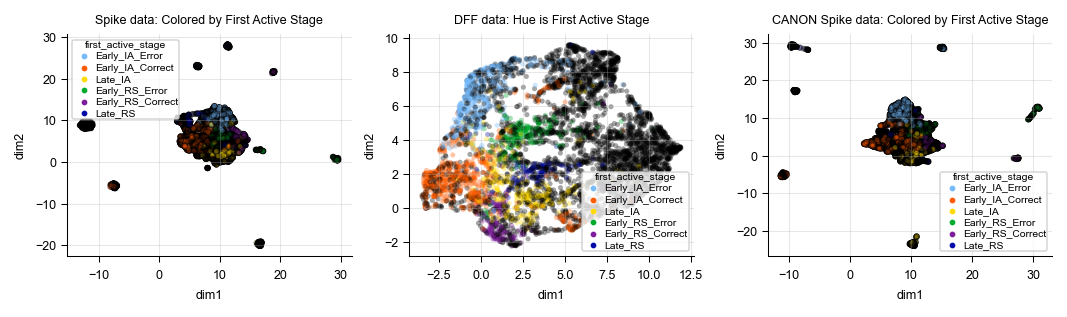

In [53]:
## PLOTTING- note that paper tSNE is projection of mean activity in stage, colored by ensemble identity
fig, axes = plt.subplots(1, 3, figsize=(7, 2), layout='constrained')
palette = [stage_palette_dict[x] for x in stage_names] + ['lightgray']
hue_col = 'first_active_stage'

#sne settings: NON ENRICHED:  s = 5,alpha = 0.35, linewidth =0.5, legend = False, palette = ['black'],  zorder=0
#ENRICHED: s = 6,alpha = 0.5, legend = make_legend, palette = [stage_palette_dict[x] for x in stage_chrono_order], hue_order =stage_chrono_order,zorder=100 )
alpha = 0.35
s_base = 6
# Spikes
sns.scatterplot(ax=axes[0], data=spikes_df, x='dim1', y='dim2', hue=hue_col,     palette=palette, hue_order=stage_names , s=s_base, alpha=alpha, edgecolor='k',linewidth=0.5, legend='full')
axes[0].set_title(f'Spike data: Colored by First Active Stage')
axes[0].grid(True, alpha=0.3)

# DFF
sns.scatterplot(ax=axes[1], data=dff_df, x='dim1', y='dim2', hue=hue_col, palette=palette, hue_order=stage_names , s=s_base, alpha=alpha, edgecolor='none',  linewidth=0.5, legend='full')
axes[1].set_title(f'DFF data: Hue is First Active Stage')
axes[1].grid(True, alpha=0.3)

# Spikes- CANON
sns.scatterplot(ax=axes[2], data=canon_spikes_df, x='dim1', y='dim2', hue=hue_col,     palette=palette, hue_order=stage_names , s=s_base, alpha=alpha, edgecolor='k',linewidth=0.5, legend='full')
axes[2].set_title(f'CANON Spike data: Colored by First Active Stage')
axes[2].grid(True, alpha=0.3)


#Final check- save manifest of config

In [54]:
subjects= unit_mean_tseries['subject_name'].unique().tolist()
enrichment_output_path = "None"
timeseries_output_path= "None"

In [55]:
# Cell: Save run manifest
runtime = time.time() - START_TIME

manifest = create_run_manifest(config=config, output_dir=run_output_dir, run_id=RUN_ID,
    inputs={'source_data': str(config['data']['source_dataset_location']),'n_subjects': len(subjects),},
    outputs={'shuffle_parquets': str(run_output_dir),
        'n_files': len(list(run_output_dir.glob('*.parquet'))),
        'enrichment_results': str(enrichment_output_path),
        'timeseries_results': str(timeseries_output_path),
    },
    performance={'runtime_seconds': int(runtime),'runtime_human': f"{runtime/3600:.1f} hours",'n_cores_used': config['shuffles']['n_cores'],},
    status={'success': True,'errors': [],'warnings': [],}
)

# Update central run log
run_db = update_run_database(manifest, db_path=results_dir / 'run_log.csv')
print(f"Run complete: {RUN_ID}")
print(f"Runtime: {runtime/3600:.1f} hours | Outputs: {run_output_dir}")
print(f"Manifest: {run_output_dir / f'run_manifest_{RUN_ID}.yaml'}")

[OK] Manifest saved to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20260118_160850\run_manifest_20260118_160850.yaml
[OK] Run database updated: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\run_log.csv
     Total runs recorded: 41
Run complete: 20260118_160850
Runtime: 17.2 hours | Outputs: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20260118_160850
Manifest: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20260118_160850\run_manifest_20260118_160850.yaml


#### TEMP- COMPARE TIMESERIES